# Predicting used car prices with linear regression
#### Dr. Bruns

In this notebook we'll use linear regression to predict the price of a used car.  The dataset we use is from 2008, and unfortunately covers only a small number of car makes.

Throughout the notebook I include "sanity checks".  I would normally not include these in a professional report.

### Instructions:
* Please read the entire notebook carefully.  It follows best practice as covered in class.
* Enter your code in the cell beneath each problem cell.
* Your code should reproduce the output in the sample output file, using methods covered in class.
* Do not modify any code except in the problem cells.
* When printing numbers, use formatted printing with f-strings.  Formats like `.3g` and `4.1f` are handy.
* Do not use ChatGPT or any other AI.  If you do use it in a problem, add a comment in that problem to say you used it.
* If you use AI on a problem and say so, you'll only get partial credit on that problem.  If you use AI on a problem and don't say so, that's an academic policy violation with serious consequences.
* Restart the kernel and run all cells before submitting!  (Otherwise a large penalty is applied.)

v1.1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from IPython.display import HTML

In [ ]:
# plotting
sns.set_theme(context='notebook', style='whitegrid')
plt.rcParams['figure.figsize'] = (5, 4)

### Read the Kuiper's 2008 car data

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/grbruns/cst383/master/kuiper-2008-cars.csv")

We'll drop the Model and Trim features, as we are interested in making predictions without identifying the exact kind of car.

In [ ]:
df.drop(['Model', 'Trim'], inplace=True, axis=1)

### Initial exploration

We first examine the size of the data set, the variable names, and whether data is missing.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 804 entries, 0 to 803
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Price     804 non-null    float64
 1   Mileage   804 non-null    int64  
 2   Make      804 non-null    object 
 3   Type      804 non-null    object 
 4   Cylinder  804 non-null    int64  
 5   Liter     804 non-null    float64
 6   Doors     804 non-null    int64  
 7   Cruise    804 non-null    int64  
 8   Sound     804 non-null    int64  
 9   Leather   804 non-null    int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 62.9+ KB


There are about 800 cars in the dataset.  There appears to be no missing data; at least not in the form of NA values.

The mileage variable refers to the number of miles a car has travelled, not the MPG of the car.

To help get a feeling of the variable types, we look at a few random rows of the dataset.

##### Problem 1.

Plot three random rows of dataframe df.  

Reproduce the model output.
    
Hint: Use the method covered in class, with random_state=0.

In [ ]:
# YOUR CODE HERE

,Price,Mileage,Make,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
8,14862.09387,24021,Buick,Sedan,6,3.1,4,1,0,1
575,16256.23617,22637,Pontiac,Sedan,6,3.8,4,1,0,0
616,15802.65286,21461,Pontiac,Wagon,4,1.8,4,0,0,0


It appears that Price, Mileage, and Liter are continuous variables, while the others are categorical.  To help confirm this, we look at the number of unique values for each variable.

##### Problem 2.

Print the number of unique values in each column of df.

Use the method discussed in class and reproduce the model output (in this and all later problems).

Don't forget the text ('Number of ...') above the output.

In [ ]:
# YOUR CODE HERE

Number of unique values per variable:
Price       798
Mileage     791
Make          6
Type          5
Cylinder      3
Liter        16
Doors         2
Cruise        2
Sound         2
Leather       2
dtype: int64


We can see that there aren't many unique values of variable Liter, which is the engine displacement (a measure of engine size).  This is a little surprising, but maybe it can be explained by the fact that only 6 makes of car are included in this dataset.

Let's look at the distributions of the continuous variables.

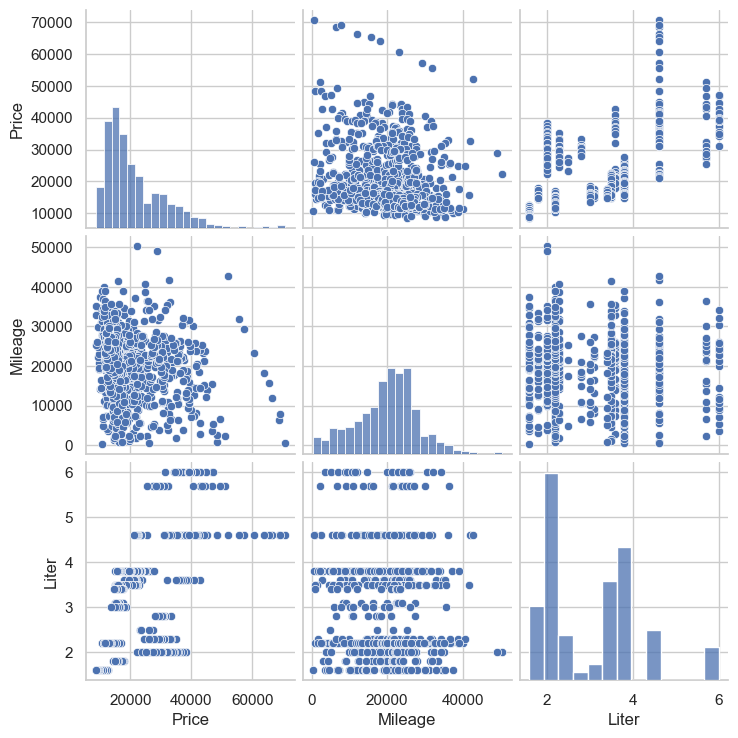

In [ ]:
sns.pairplot(data=df[['Price', 'Mileage', 'Liter']])
plt.show()

This plot shows scatterplots for pairs of variables, and histograms for single variables.

Looking at the single variables, Mileage appears to have a roughly normal distribution, while Price has a positive skew.  Also, there appear to be some clear outliers for the Price variable.

Liter and Price appear positively correlated, which intuitively means that bigger cars are more expensive.  It also makes sense that cars with higher mileage appear to cost less.

We use a box plot to identify outliers of Price and Mileage.

##### Problem 3.

Reproduce the multi-boxplot shown in the model output using methods covered in class.

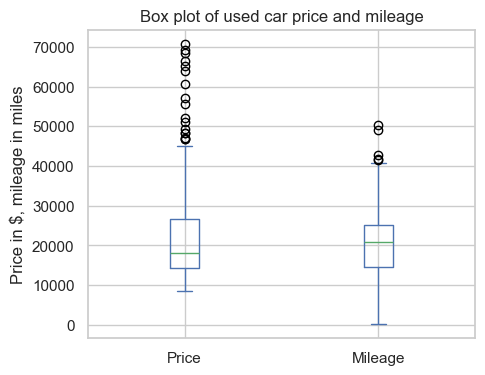

In [ ]:
# YOUR CODE HERE

The median car price is about \\$18,000, and an outlier is considered to be a price greater than about \\$45,000.  There are a much smaller number of outliers with respect to mileage.  Surprisingly, no car in the dataset has more than 50,000 miles, and 40,000 and above are considered outliers.

The large price values are a concern, as we will be trying to predict price, and it will be difficult for our model to do well with outliers.  We may drop the outliers before performing machine learning.

### Data preprocessing

In initial exploration we found no missing or bad values, although we did find outliers.  We will treat outliers later, in preparation for machine learning.

### Data exploration

In this section we will briefly look at the relationships of car features to price.  First we'll look at the average price for different makes and types.

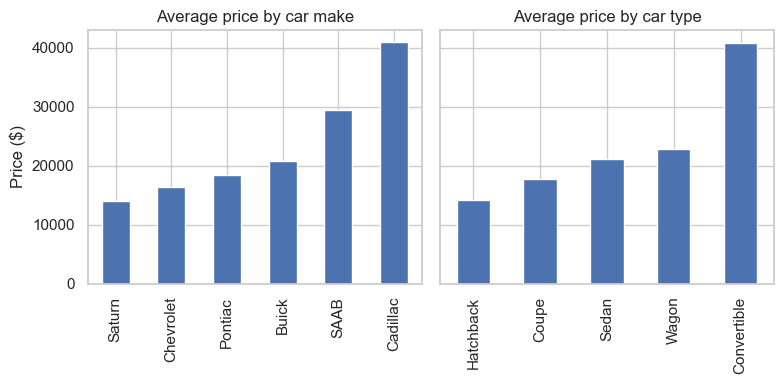

In [ ]:
fig,axs = plt.subplots(1, 2, figsize=(8,4), sharey=True)
df.groupby('Make')['Price'].mean().sort_values().plot.bar(ax=axs[0])
axs[0].set_title('Average price by car make')
axs[0].set_xlabel('')
axs[0].set_ylabel('Price ($)')
df.groupby('Type')['Price'].mean().sort_values().plot.bar(ax=axs[1])
axs[1].set_title('Average price by car type')
axs[1].set_xlabel('')
plt.tight_layout()
plt.show()

Only a few car makes are represented in the dataset.  Cadillac is the most expensive make.  By far, convertibles are more expensive than other types.  It is interesting that 'Truck' and 'SUV' types is not included.  I believe SUVs were popular in 2008.  

We perform similar analysis for the features Cruise, Sound, and Leather, which may be associated with more expensive cars.

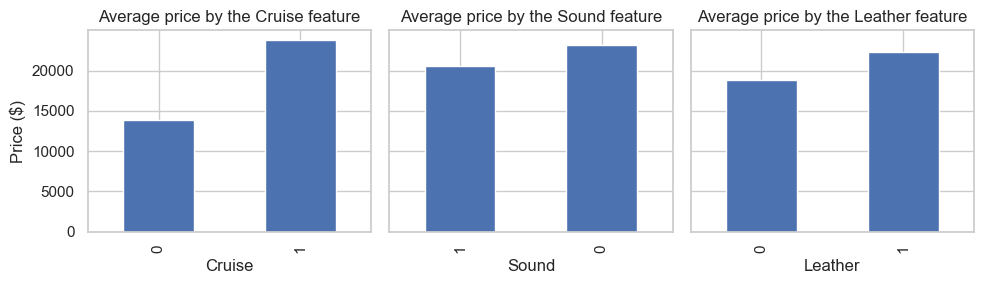

In [ ]:
features = ['Cruise', 'Sound', 'Leather']
fig,axs = plt.subplots(1, len(features), figsize=(10,3), sharey=True)
for i, feature in enumerate(features):
    df.groupby(feature)['Price'].mean().sort_values().plot.bar(ax=axs[i])
    axs[i].set_title(f'Average price by the {feature} feature')
axs[0].set_ylabel('Price ($)')
plt.tight_layout()
plt.show()

It is surprising that the cruise control feature is the biggest differentiator in price among these three features.

### Machine learning

We will build a model to predict a used car's price from its mileage and features.  As a first step, we have to do some data preparation.

#### Data preprocessing for machine learning

Drop the outliers in the price variable.  We use the boxplot concept of outlier, but consider upper outliers only.

##### Problem 4.

Modify dataframe df to remove rows containing "upper" Price outlier values.

As part of doing this, define variable `upper_outlier_threshold`.  This is the value no Price value can exceed.

Do not worry about Price values that are very small.

Hint: recall how upper outliers are defined in boxplots:
- A value is an upper outlier if it's greater than Q3 + 1.5 * IQR, where Q1 and Q3 are the first and third quartiles, and IQR is the "inter quartile range".
- See the lecture on visualizing one continuous variable for details.

In [ ]:
# YOUR CODE HERE

Sanity check: print the threshold and see how many rows remain after dropping outliers.  The threshold should be consistent with the Price boxplot shown earlier.

In [ ]:
print(f"threshold: ${upper_outlier_threshold:.0f}")
print(f"number of rows after dropping price outliers: {df.shape[0]}")

threshold: $45384
number of rows after dropping price outliers: 787


Now we need to ensure that all categorical variables are transformed correctly to numeric values.

##### Problem 5.

Transform the categorical variables to quantitative variables using the method covered in class.

Make sure your result exactly matches the model output below.

Hint: most of the categorical variables, such as Leather, are already in the right form.

In [ ]:
# YOUR CODE HERE

Sanity check: see the new variables of the dataset.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 787 entries, 0 to 803
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Price           787 non-null    float64
 1   Mileage         787 non-null    int64  
 2   Cylinder        787 non-null    int64  
 3   Liter           787 non-null    float64
 4   Doors           787 non-null    int64  
 5   Cruise          787 non-null    int64  
 6   Sound           787 non-null    int64  
 7   Leather         787 non-null    int64  
 8   Make_Cadillac   787 non-null    int32  
 9   Make_Chevrolet  787 non-null    int32  
 10  Make_Pontiac    787 non-null    int32  
 11  Make_SAAB       787 non-null    int32  
 12  Make_Saturn     787 non-null    int32  
 13  Type_Coupe      787 non-null    int32  
 14  Type_Hatchback  787 non-null    int32  
 15  Type_Sedan      787 non-null    int32  
 16  Type_Wagon      787 non-null    int32  
dtypes: float64(2), int32(9), int64(6)
memory

That the type of the dummy variables is bool, not int as specified in the get_dummies() call.  This appears to be a bug in the version of Pandas being used here.  The bool type should work fine, however.

Compute the X, y numpy arrays, using price as the target variable.

In [ ]:
predictors = df.columns.drop('Price')
target = 'Price'
X = df[predictors].values
y = df[target].values

Perform a train/test split.  Use 25% of the data for the test set.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

Sanity check: examine the shape of X_train and y_train.

In [ ]:
print(X_train.shape, y_train.shape)

(590, 16) (590,)


#### Computing baseline RMSE and MAE

The baseline RMSE value should be based on the mean of the target value in the training data.  The baseline MAE value should be based on the median of the target value in the training data.

##### Problem 6.

Compute baseline RMSE and MAE values.

The baseline RMSE value must be assigned to baseline_rmse, and
the baseline MAE value must be assigned to baseline_mae.

Hint: pay attention to text in preceding cells.

In [ ]:
# YOUR CODE HERE

In [ ]:
print(f'baseline RMSE: {baseline_rmse:5.1f}, baseline MAE: {baseline_mae:5.1f}')

baseline RMSE: 8689.7, baseline MAE: 6760.8


These baseline values are large.  The baseline MAE says that if we always predict the median used car value, on average our absolute error will be over \\$6,000.

#### Linear regression

In [ ]:
regr = LinearRegression()

Compute the cross-validation RMSE and MAE.

##### Problem 7.

Compute CV RMSE and MAE values.

The CV RMSE value must be assigned to cv_rmse, and
the CV MAE value must be assigned to cv_mae.

Hint: use the 'scoring' parameter of cross_val_score() to get the right output.

In [ ]:
# YOUR CODE HERE

In [ ]:
print(f'CV RMSE: {cv_rmse:5.1f}, CV MAE: {cv_mae:5.1f}')

CV RMSE: 2015.8, CV MAE: 1525.9


This is a huge improvement over the baseline values.  Now, on average our predictions will have an absolute error of about \\$1,500, compared to the baseline of about \\$6,300.

Let's look at the coefficients of our model.

In [ ]:
regr.fit(X_train, y_train);    # semi-colon used to suppress the useless output

In [ ]:
coefs = pd.Series(regr.coef_, index=predictors)
print('Model coefficients:')
print(f"Intercept: {regr.intercept_:4.1f}")
print(coefs.round(1))

Model coefficients:
Intercept: 26942.6
Mileage              -0.2
Cylinder          -1849.5
Liter              6460.5
Doors             -3422.7
Cruise              190.9
Sound              -232.4
Leather             209.2
Make_Cadillac     14515.3
Make_Chevrolet    -1455.1
Make_Pontiac      -1729.3
Make_SAAB         11699.2
Make_Saturn       -1450.6
Type_Coupe        -8339.4
Type_Hatchback    -1667.5
Type_Sedan        -1649.0
Type_Wagon         1605.2
dtype: float64


The coefficient of Mileage is -0.2, which means that if the mileage value increases by 1, the price decreases by \\$0.20, which is 20 cents.  The coefficient of Liter is 6460.5, which means that if the engine displacement is increased by 1 Liter, the price increases by \\$6460.50.

The values of the coefficients don't tell you anything about how useful the predictors are in helping to make predictions.

If we scale the predictors, so they're all on the same scale, the relative values of the coefficients is interesting.

##### Problem 8.

Scale the training and test data using z-score normalization.

Use the method covered in class.  You will overwrite the current values of X_train and X_test.

Hint: look at the imports of this file.
    
Hint: be sure not to use fit() on test data -- that would be peeking at the test data.

In [ ]:
# YOUR CODE HERE

Sanity check: compute the means of X_train and X_test.  

Both X_train and X_test were scaled using data in X_train.  Therefore the average value in X_train should be very close to 0, and the average value in X_train should be fairly close to 0.

In [ ]:
print(f"{X_train.mean():0.5g}")
print(f"{X_test.mean():0.5g}")

4.7758e-16
-0.013292


Train the linear regression model on the training data, which is now scaled.

##### Problem 9.

Train the linear regression object, which was created earlier.

Make no predictions, just train the model.

Hint: I used a semicolon to suppress unwanted output.

In [ ]:
# YOUR CODE HERE

First we'll examine the intercept coefficient.

In [ ]:
print(f"intercept: {regr.intercept_:4.1f}")

intercept: 20851.1


A way to think about the intercept is that it is our starting price, which will then be modified using the other model coefficients.

Now we plot the coefficients associated with each of the predictor variables.

The relative sizes of the coefficients are meaningful because we scaled the training data.

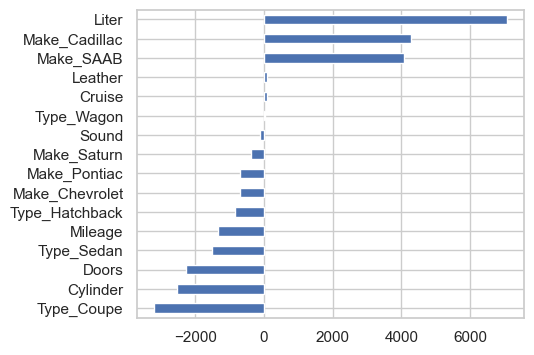

In [ ]:
# the axes are saved because I will want to use the xlimit values of this
# plot in a later plot
ax = pd.Series(regr.coef_, index=predictors).sort_values().plot.barh()
xlim = ax.get_xlim()   # a tuple (xmin, xmax)
plt.show()

Variables associated with positive coefficients are variables that lead to higher predicted prices.  For example, if the car is a Cadillac, it gets a \\$4,000 price boost.  Larger engines are associated with higher prices, too.  But coupes and cars with high mileage are associated with lower prices.

I'm surprised that the 'Cylinder' variable has a negative coefficient, as more cylinders usually means the displacement of the engine is larger, which appears to be associated with higher prices.  However, remember that the coefficient for a variable depends on all the other predictor variables that are included.

This problem is related to a subtle issue with linear regression: if you want the coefficients to be meaningful, avoid including predictor variables that are strongly correlated with each other.

Let's try using linear regression one more time, but without the Cylinder variable.  To do this, we want to drop the column of X_train and X_test that correspond to Cylinder.

In [ ]:
predictor_mask = np.array(predictors) != 'Cylinder'
X_train = X_train[:,predictor_mask]
X_test  = X_test[:,predictor_mask]
predictors = predictors.drop('Cylinder')

In [ ]:
cv_rmse = -cross_val_score(regr, X_train, y_train, scoring='neg_root_mean_squared_error').mean()
cv_mae  = -cross_val_score(regr, X_train, y_train, scoring='neg_mean_absolute_error').mean()
print(f'CV RMSE: {cv_rmse:5.1f}, CV MAE: {cv_mae:5.1f}')

CV RMSE: 2079.2, CV MAE: 1575.4


We find that our CV mean absolute error is about the same as before.  

Now let's plot the coefficients again.

In [ ]:
regr.fit(X_train, y_train);

##### Problem 10.

Print the intercept coefficient value and plot the coefficients of the trained linear regression model.

Your plot should match the model output.

Hint: it will help to use variable xlim, which is already defined.

intercept: 20851.1


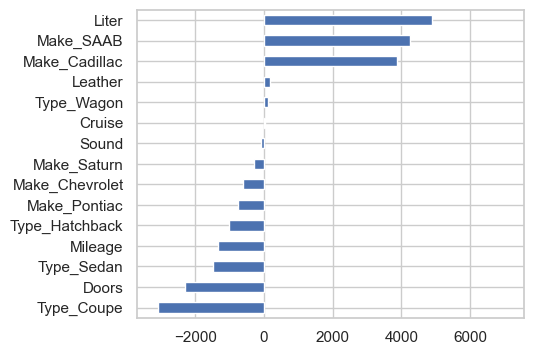

In [ ]:
# YOUR CODE HERE

Even though our model is the same except that 'Cylinders' is no longer a predictor, all of the coefficients have changed a little.
It's important to understand that the coefficients of a linear model work together: the coefficient of one predictor depends on which other predictors are present.

For example, the coefficient for Liter has changed from about 7000 to about 5000, which is a big difference.  You can also see that the coefficient for Make_SAAB is now larger than the coefficient for Make_Cadillac.

We now compute the performance of our model on the test data.  We have not used the test data at all yet, so it's a good measure of how we can expect to do on data we've never seen before.

In [ ]:
y_pred = regr.predict(X_test)

test_rmse = np.sqrt(((y_pred - y_test)**2).mean())
test_mae  = np.abs(y_pred - y_test).mean()
print(f'test RMSE: {test_rmse:5.1f}, test MAE: {test_mae:5.1f}')

test RMSE: 2001.1, test MAE: 1499.6


We learn that we can expect, on average, to be wrong on price predictions by about \\$1,500 on average.

As another way of understanding our model, let's look at an actuals/predicted plot.

##### Problem 11.

Produce a predicted/actuals plot that matches the model output.

Hint: the easiest way to plot the dashed "perfect prediction" line is with plt.axline().

Hint: code for a predicted/actuals plot was shared in a class lecture.

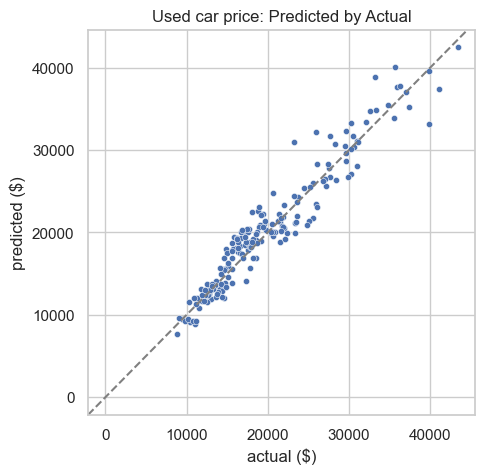

In [ ]:
# YOUR CODE HERE

We want the points to be as close to the dotted line as possible.  This plot looks pretty good.  It is not surprising that the predictions appear to get worse as the cars get more expensive (higher actual price).

We looked at the coefficients of the scaled predictors to get an idea of which predictors are the most useful.

Another way to see if a predictor is useful is to see good our predictions would be if we used only that one predictor in our model.

In [ ]:
rmses = []
for i, pred in enumerate(predictors):
    cv_rmse = -cross_val_score(regr, X_train[:,[i]], y_train, scoring='neg_root_mean_squared_error').mean()
    rmses.append(cv_rmse)

We plot the CV RMSE for each predictor as a bar plot.

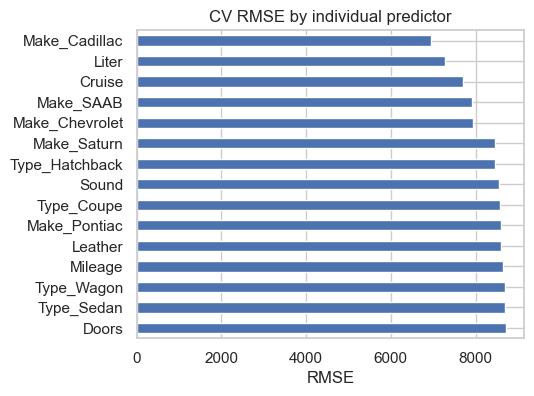

In [ ]:
rmses = pd.Series(rmses, index=predictors)
rmses.sort_values(ascending=False).plot.barh(title="CV RMSE by individual predictor")
plt.xlabel('RMSE')
plt.show()

This plot says that, if we could only use one predictor, it should be Make_Cadillac.  The baseline RMSE is about 8690, and some of the predictors appear to do no better than baseline on their own.

##### Problem 12.  

Write a paragraph about three interesting or important things you learned about linear regression from this assignment.

Enter your text in the markdown cell below.

(replace this with your text)